# The Geography of the Attack

Starting from the 63 raw DataVolley `.dvw` files stored on Google Drive, this notebook decodes the scouting data using `pydatavolley`, generates the static Matplotlib and Seaborn figures used in the Technical Report, and builds the interactive Bokeh prototype (Deliverable 3). The interactive visualization includes a court diagram, a ranked attack-efficiency chart, tempo-based heatmaps, a blocking-pressure analysis (front-row vs. back-row attacks), and a match-level attack volume versus efficiency view.

**A note on `num_blockers == 4`.** The `num_blockers` variable is extracted by `pydatavolley` from a fixed position in the DataVolley action code. The values from 0 to 3 behave as expected, with attack efficiency decreasing as the number of opposing blockers increases. An additional value (`4`) also appears consistently across the dataset, although an attack cannot face four front-row blockers. The value corresponds to the DataVolley category 'Hole block': the attack passes through a gap in the block rather than facing a literal count of blockers.

Rather than removing this value or merging it with other categories, it is kept as a separate category (`4*`). As shown in the Technical Report, it appears in all 63 matches and follows a consistent pattern across the dataset.

The notebook parses the raw `.dvw` files, creates the intermediate `matches.csv` and `actions.csv` files, and then generates all analyses and figures.

## Dataset

- **Source:** 63 DataVolley `.dvw` files (Italian Women's Serie A2, 2025/26)
- **Location:** Google Drive (default path shown below)

## GitHub

- Repository:

## 0. Install pydatavolley and Bokeh

In [1]:
!pip install -q pydatavolley bokeh

  Preparing metadata (setup.py) ... done


## 1. Load the data from Google Drive

Mounts Drive and points at the folder holding all 63 `.dvw` files.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

dvw_folder = "/content/drive/MyDrive/database_datavolley"


Mounted at /content/drive


## 2. Parse the `.dvw` files into `matches.csv` and `actions.csv`

Uses `pydatavolley` to parse the raw DataVolley files and extract the action-level information (team, player, skill, evaluation code, attack zone, and number of blockers).

The attack tempo is recovered by reading the match-specific `[3ATTACKCOMBINATION]` table, since this information is not provided as a separate field by `pydatavolley`. The attack zone comes directly from `pydatavolley` (`start_zone`) and was cross-checked against the corresponding `[3ATTACKCOMBINATION]` table, giving 100% agreement across all 8,312 focal-team attacks.

In [3]:
import glob
import os
import pandas as pd
import numpy as np

# Compatibility pydatavolley - NumPy
# (NumPy2.0 in Colab, NumPy in pydatavolley)
# NumPy2.0 no longer allows NaN
if not hasattr(np, "NaN"):
    np.NaN = np.nan

# Compatibility pydatavolley - NumPy
# NumPy2.0 no longer allows mixed string/NaN outputs in np.where
if not getattr(np.where, "_is_lenient_where_patch", False):
    _original_where = np.where
    def _lenient_where(condition, x=None, y=None):
        if x is None and y is None:
            return _original_where(condition)
        try:
            return _original_where(condition, x, y)
        except TypeError:
            pass
        except Exception as e:
            if type(e).__name__ != "DTypePromotionError":
                raise
        condition = np.asarray(condition)
        out = np.empty(condition.shape, dtype=object)
        out[:] = y
        out[condition] = x
        return out
    _lenient_where._is_lenient_where_patch = True
    np.where = _lenient_where

In [4]:
from datavolley import read_dv

DVW_DIR = dvw_folder
OUT_DIR = "."

PHASE_MAP = {
    "rs": "Regular Season", "pp": "Playoff Pool",
    "pofi": "Playoffs - Final", "poqf": "Playoffs - Quarterfinal", "posf": "Playoffs - Semifinal",
    "cifi": "Coppa Italia - Final", "ciqf": "Coppa Italia - Quarterfinal", "cisf": "Coppa Italia - Semifinal",
}

SKILL_TO_LETTER = {
    "Serve": "S", "Reception": "R", "Set": "E", "Attack": "A",
    "Block": "B", "Dig": "D", "Freeball": "F",
}

# pydatavolley doesn't parse the attack-combination tempo field
# and the phase/round
def read_raw_lines(path):
    raw = open(path, encoding="latin-1").read()
    return [l.rstrip("\r") for l in raw.split("\n")]


def section(lines, name):
    header = f"[3{name}]"
    if header not in lines:
        return []
    i = lines.index(header)
    out = []
    for l in lines[i + 1:]:
        if l.startswith("[3"):
            break
        if l.strip() != "":
            out.append(l)
    return out

# read [3ATTACKCOMBINATION] section in order to structure the tempo field
# pydatavolley's get_attack_combinations() only keeps a free-text
# description per code
def read_attack_tempo_table(lines):
    rows = section(lines, "ATTACKCOMBINATION")
    tempo_by_code = {}
    for r in rows:
        f = r.split(";")
        if len(f) >= 5:
            tempo_by_code[f[0]] = f[3]
    return tempo_by_code


def phase_and_round(filename):
    base = os.path.basename(filename)
    prefix = base.split("_")[0].lstrip("&")
    i = 0
    while i < len(prefix) and prefix[i].isalpha():
        i += 1
    if i == 0:
        phase_key, round_num = prefix, ""
    else:
        j = i
        while j < len(prefix) and prefix[j].isdigit():
            j += 1
        phase_key, round_num = prefix[:i], prefix[i:j]
    return PHASE_MAP.get(phase_key, phase_key), round_num


def process_file(path):
    dv = read_dv.DataVolley(path)
    plays = dv.get_plays()

    lines = read_raw_lines(path)
    tempo_by_code = read_attack_tempo_table(lines)
    phase, round_num = phase_and_round(path)

    match_id = os.path.basename(path).replace(".dvw", "").lstrip("&")

    team_code_by_name = {dv.home_team: dv.home_team_id, dv.visiting_team: dv.visiting_team_id}
    team_side_by_name = {dv.home_team: "home", dv.visiting_team: "away"}

    rows = plays[plays["skill"].isin(SKILL_TO_LETTER.keys())].copy()
    rows["team_code"] = rows["team"].map(team_code_by_name)
    rows["team_side"] = rows["team"].map(team_side_by_name)
    rows["skill_letter"] = rows["skill"].map(SKILL_TO_LETTER)
    rows["tempo"] = rows["attack_code"].map(tempo_by_code)

    actions = []
    for idx, r in enumerate(rows.to_dict("records")):
        actions.append({
            "match_id": match_id,
            "row_idx": idx,
            "set_number": r.get("set_number"),
            "team_side": r["team_side"],
            "team_code": r["team_code"],
            "jersey": r["player_number"],
            "player_name": r["player_name"],
            "skill": r["skill_letter"],
            "evaluation": r["evaluation_code"] if pd.notna(r["evaluation_code"]) else "",
            "combo_code": r["attack_code"] if pd.notna(r["attack_code"]) else "",
            "zone": r["start_zone"] if pd.notna(r["start_zone"]) else "",
            "side": "",  # not needed downstream; tempo is what we use from the combo table
            "tempo": r["tempo"] if pd.notna(r["tempo"]) else "",
            "attack_desc": r.get("attack_description") if pd.notna(r.get("attack_description")) else "",
            "num_blockers": r["num_players_numeric"] if pd.notna(r["num_players_numeric"]) else "",
        })

    match_row = {
        "match_id": match_id,
        "date": dv.match_info.day if dv.match_info is not None else None,
        "phase": phase,
        "round": round_num,
        "home_code": dv.home_team_id,
        "home_name": dv.home_team,
        "away_code": dv.visiting_team_id,
        "away_name": dv.visiting_team,
        "num_sets_recorded": len(dv.sets_info) if dv.sets_info is not None else None,
        "n_scout_lines": len(plays),
        "n_decoded_actions": len(actions),
    }
    return match_row, actions


def parse_all():
    if not os.path.isdir(DVW_DIR):
        raise FileNotFoundError(
            f"DVW_DIR does not exist: {DVW_DIR!r}. Check that Drive is mounted "
        )
    files = sorted(
        glob.glob(os.path.join(DVW_DIR, "*.dvw")) +
        glob.glob(os.path.join(DVW_DIR, "*.DVW"))
    )
    if not files:
        contents = os.listdir(DVW_DIR)
        raise FileNotFoundError(
            f"DVW_DIR exists ({DVW_DIR!r}) but no .dvw files were found directly "
            f"inside it."
        )
    print(f"Found {len(files)} .dvw files")
    all_matches, all_actions, errors = [], [], []
    for f in files:
        try:
            match_row, actions = process_file(f)
            all_matches.append(match_row)
            all_actions.extend(actions)
        except Exception as e:
            errors.append((f, e))
            print("ERROR", f, repr(e))

    if not all_matches:
        first_file, first_exc = errors[0]
        print(f"\n{len(errors)} / {len(files)} files failed. First failure was on {first_file!r}.\n")
        raise RuntimeError(
            f"Every one of the {len(files)} .dvw files raised an error during parsing "
            f"-- nothing to write to matches.csv / actions.csv."
        ) from first_exc

    pd.DataFrame(all_matches).to_csv(os.path.join(OUT_DIR, "matches.csv"), index=False)
    pd.DataFrame(all_actions).to_csv(os.path.join(OUT_DIR, "actions.csv"), index=False)

    print(f"matches: {len(all_matches)}, actions: {len(all_actions)}, errors: {len(errors)}")

parse_all()


Found 63 .dvw files


/usr/local/lib/python3.12/dist-packages/datavolley/get_players_from_md.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  team_players['nickname'].fillna("", inplace=True)
/usr/local/lib/python3.12/dist-packages/datavolley/get_players_from_md.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beha

matches: 63, actions: 69943, errors: 0


**Problems fixed**
*   **Attack tempo is not decoded by pydatavolley**:

pydatavolley extracts the team, player, skill, evaluation code, and attack zone (start_zone), but it does not decode the attack-combination code (e.g. X1) into the corresponding attack tempo.
This information is available in the `[3ATTACKCOMBINATION]` section of each .dvw file. The helper function read_attack_tempo_table reads this table and assigns the corresponding tempo to each attack action.

* **Attack zone is available from two different sources**:

`pydatavolley` provides the attack zone as `start_zone`, extracted from a fixed position in the action code. The same information is also available as text in the `[3ATTACKCOMBINATION]` table.

Before deciding which source to use, the two were compared across all focal-team attack actions. They matched in every case, so the `start_zone` field provided by `pydatavolley` was used in the analysis.

* **An unexpected fourth value in `num_blockers`**:

The values from 0 to 3 behave as expected, with attack efficiency decreasing as the number of opposing blockers increases. However, a fourth value (`4`) also appears. Since an attack cannot face four front-row blockers, this value could not be interpreted directly.

Before using `num_blockers` in the analysis, it was therefore necessary to determine whether this category reflected random scouting noise or a real systematic pattern in the dataset.

In [5]:
# inspect the data directly to verify the issue described above
_check = pd.read_csv(os.path.join(OUT_DIR, "actions.csv"), dtype=str)
blk = _check[_check.num_blockers.isin(["0", "1", "2", "3", "4"])].copy()

rate_by_match = blk.groupby("match_id").apply(
    lambda g: (g.num_blockers == "4").mean() * 100
)
print(f"'4' appears in {(rate_by_match > 0).sum()} / {len(rate_by_match)} matches")
print(f"rate per match: min {rate_by_match.min():.1f}%, max {rate_by_match.max():.1f}%, "
      f"mean {rate_by_match.mean():.1f}%")

blk["_is_4"] = blk.num_blockers == "4"
blk["_is_quick"] = blk.tempo == "Q"
blk["_one"] = 1
counts = blk.pivot_table(index="_is_4", columns="_is_quick", values="_one", aggfunc="sum", fill_value=0)
tempo_skew = (counts.T / counts.sum(axis=1)).T * 100
tempo_skew.index = ["num_blockers != 4", "num_blockers == 4"]
tempo_skew.columns = ["tempo != Quick", "tempo == Quick"]
print()
print("Share of Quick-tempo attacks, by whether num_blockers == 4:")
print(tempo_skew.round(1))


'4' appears in 63 / 63 matches
rate per match: min 1.9%, max 15.0%, mean 6.6%

Share of Quick-tempo attacks, by whether num_blockers == 4:
                   tempo != Quick  tempo == Quick
num_blockers != 4            85.6            14.4
num_blockers == 4            44.2            55.8


/tmp/ipykernel_1355/3591151243.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rate_by_match = blk.groupby("match_id").apply(


The fourth value appears in all 63 matches, with a fairly consistent frequency (about 6.6% of attacks on average, never zero). It is also much more common in quick attacks (56% of the `"4"` cases, compared with 14% in the rest of the data), suggesting that it is unlikely to be a random scouting error.

Searching in the official documentation, we found out the value corresponds to the DataVolley category 'Hole block' (the attack passes through a gap in the block rather than facing a literal count of blockers).



## 3. Exploratory figures for the Technical Report

This section creates all the figures used in the Technical Report. They are generated from the `actions.csv` and `matches.csv` files produced by the parser, so the results can always be reproduced from the original `.dvw` files.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
EDA_DIR = "."

actions = pd.read_csv(f"{EDA_DIR}/actions.csv", dtype=str)
matches = pd.read_csv(f"{EDA_DIR}/matches.csv", dtype=str)

FOCAL = ["BRE", "TAL"]
TEAM_LABEL = {"BRE": "Brescia", "TAL": "Talmassons"}
TEAM_COLOR = {"Brescia": "#ffd010", "Talmassons": "#c11471"}

attacks = actions[actions.skill == "A"].copy()
attacks_f = attacks[attacks.team_code.isin(FOCAL)].copy()
attacks_f["team_label"] = attacks_f.team_code.map(TEAM_LABEL)

TEMPO_LABEL = {"Q": "Quick", "H": "High ball", "U": "Super",
               "M": "Medium", "O": "Second ball / other", "N": "No-attack / rare"}
attacks_f["tempo_label"] = attacks_f.tempo.map(TEMPO_LABEL).fillna(attacks_f.tempo)

def eff_stats(df, group_cols):
    g = df.groupby(group_cols)
    out = g.agg(n=("evaluation", "size"),
                kills=("evaluation", lambda s: (s == "#").sum()),
                errors=("evaluation", lambda s: (s == "=").sum())).reset_index()
    out["kill_rate"] = out["kills"] / out["n"]
    out["error_rate"] = out["errors"] / out["n"]
    out["efficiency"] = (out["kills"] - out["errors"]) / out["n"]
    return out

zone_order = ["2", "3", "4", "8", "9"]
zone_label = {"2": "Zone 2 (opposite)", "3": "Zone 3 (center)", "4": "Zone 4 (outside)",
              "8": "Zone 8 (pipe)", "9": "Zone 9 (back-r. diag.)"}
FRONT_ZONES = {"2", "3", "4"}
BACK_ZONES = {"8", "9"}

def grouped_bar(ax, cats, valA, valB, labelA, labelB, colorA, colorB, ylabel):
    x = np.arange(len(cats))
    width = 0.35
    ax.bar(x - width / 2, valA, width, color=colorA, label=labelA)
    ax.bar(x + width / 2, valB, width, color=colorB, label=labelB)
    ax.set_xticks(x)
    ax.set_xticklabels(cats, rotation=20, ha="right")
    ax.set_ylabel(ylabel)
    ax.legend(loc="best", frameon=True)


### Figure 1: dataset composition. Actions logged by skill and outcome grade

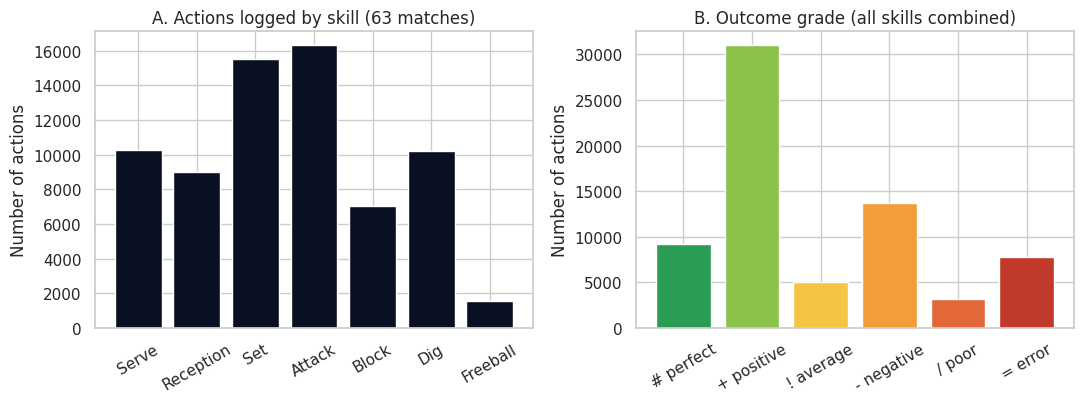

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
skill_order = ["S", "R", "E", "A", "B", "D", "F"]
skill_label = {"S": "Serve", "R": "Reception", "E": "Set", "A": "Attack",
               "B": "Block", "D": "Dig", "F": "Freeball"}
skill_counts = actions.skill.value_counts().reindex(skill_order)
axes[0].bar([skill_label[s] for s in skill_order], skill_counts.values, color="#091021")
axes[0].set_title("A. Actions logged by skill (63 matches)")
axes[0].set_ylabel("Number of actions")
axes[0].tick_params(axis="x", rotation=30)

eval_order = ["#", "+", "!", "-", "/", "="]
eval_label = {"#": "# perfect", "+": "+ positive", "!": "! average",
              "-": "- negative", "/": "/ poor", "=": "= error"}
eval_counts = actions.evaluation.value_counts().reindex(eval_order)
colors = ["#2a9d54", "#8bc34a", "#f4c542", "#f39c3a", "#e2683a", "#c0392b"]
axes[1].bar([eval_label[e] for e in eval_order], eval_counts.values, color=colors)
axes[1].set_title("B. Outcome grade (all skills combined)")
axes[1].set_ylabel("Number of actions")
axes[1].tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(f"{EDA_DIR}/fig1_overview.png", dpi=160)


### Figure 2: attack volume by zone, Brescia vs Talmassons (grouped bar chart)

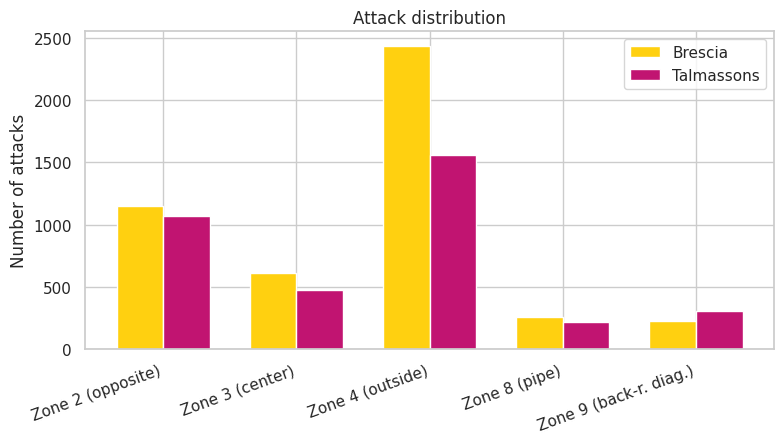

In [8]:
zv = eff_stats(attacks_f, ["team_label", "zone"])
pivot_n = zv.pivot_table(index="zone", columns="team_label", values="n").reindex(zone_order)

fig, ax = plt.subplots(figsize=(8, 4.6))
grouped_bar(ax, [zone_label[z] for z in zone_order],
            pivot_n["Brescia"], pivot_n["Talmassons"],
            "Brescia", "Talmassons", TEAM_COLOR["Brescia"], TEAM_COLOR["Talmassons"],
            "Number of attacks")
ax.set_title("Attack distribution")
fig.tight_layout()
fig.savefig(f"{EDA_DIR}/fig2_attack_distribution.png", dpi=160)


### Figure 3: attack zones and court division

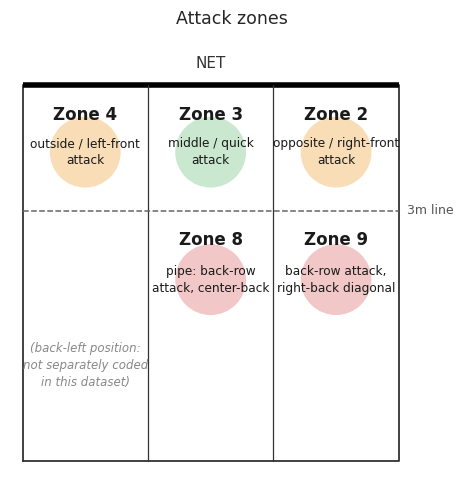

In [9]:
ZONES = {
    4: {"x": 1.5, "title_y": 8.3, "mark_y": 7.4, "color": "#f4c27a",
        "subtitle": "outside / left-front\nattack"},
    3: {"x": 4.5, "title_y": 8.3, "mark_y": 7.4, "color": "#9fd6a8",
        "subtitle": "middle / quick\nattack"},
    2: {"x": 7.5, "title_y": 8.3, "mark_y": 7.4, "color": "#f4c27a",
        "subtitle": "opposite / right-front\nattack"},
    8: {"x": 4.5, "title_y": 5.3, "mark_y": 4.35, "color": "#e79a9a",
        "subtitle": "pipe: back-row\nattack, center-back"},
    9: {"x": 7.5, "title_y": 5.3, "mark_y": 4.35, "color": "#e79a9a",
        "subtitle": "back-row attack,\nright-back diagonal"},
}

fig, ax = plt.subplots(figsize=(7.2, 5))

# Court boundary + net
ax.plot([0, 9, 9, 0, 0], [0, 0, 9, 9, 0], color="#333333", lw=1.3)
ax.plot([0, 9], [9, 9], color="black", lw=4, solid_capstyle="butt")
ax.text(4.5, 9.35, "NET", ha="center", va="bottom", fontsize=11, color="#333333")

# Column dividers
ax.plot([3, 3], [0, 9], color="#333333", lw=0.9)
ax.plot([6, 6], [0, 9], color="#333333", lw=0.9)

# 3 m line (dashed), with a label to the right of the court
ax.plot([0, 9], [6, 6], color="#666666", lw=1.1, linestyle="dashed")
ax.text(9.2, 6, "3m line", ha="left", va="center", fontsize=9, color="#555555")

for zone, z in ZONES.items():
    ax.text(z["x"], z["title_y"], f"Zone {zone}", ha="center", va="center",
            fontsize=12, fontweight="bold", color="#1a1a1a")
    ax.scatter([z["x"]], [z["mark_y"]], s=2600, color=z["color"], alpha=0.55,
               edgecolor="none", zorder=2)
    ax.text(z["x"], z["mark_y"], z["subtitle"], ha="center", va="center",
            fontsize=8.7, color="#1a1a1a", linespacing=1.4, zorder=3)

# Back-left cell: no attack data for this position in the dataset
ax.text(1.5, 2.3,
        "(back-left position:\nnot separately coded\nin this dataset)",
        ha="center", va="center", fontsize=8.5, color="#888888",
        style="italic", linespacing=1.4)

ax.set_xlim(-0.3, 10.3)
ax.set_ylim(-0.3, 10.0)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Attack zones",
              fontsize=12.5, pad=14)

fig.tight_layout()
fig.savefig("fig3_attack_zones.png", dpi=200, bbox_inches="tight")


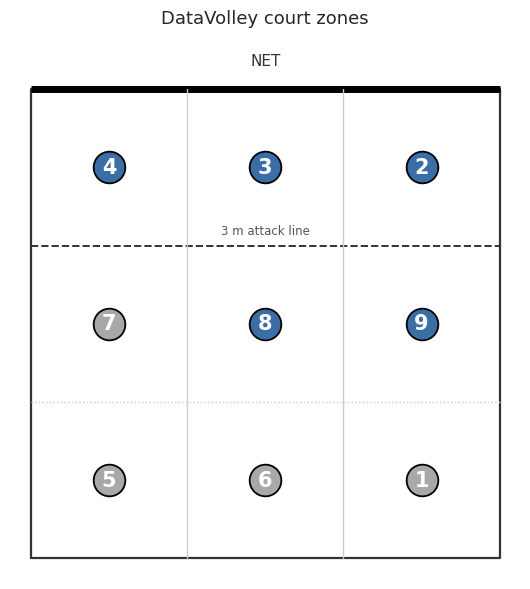

In [10]:
ZONE_GRID = {
    4: (1.5, 7.5), 3: (4.5, 7.5), 2: (7.5, 7.5),   # front row
    7: (1.5, 4.5), 8: (4.5, 4.5), 9: (7.5, 4.5),   # middle row
    5: (1.5, 1.5), 6: (4.5, 1.5), 1: (7.5, 1.5),   # back row
}

USED_ZONES = {2, 3, 4, 8, 9}
ZONE_NAME = {
    2: "opposite", 3: "center", 4: "outside",
    8: "pipe", 9: "back-right diagonal",
    1: "back right", 5: "back left", 6: "back center", 7: "back left (pipe-side, unused here)",
}
ZONE_ORDER = [4, 3, 2, 7, 8, 9, 5, 6, 1]
USED_COLOR = "#3b6ea5"
UNUSED_COLOR = "#a8a8a8"

fig = plt.figure(figsize=(10.5, 6.3))
ax = fig.add_axes([0.03, 0.06, 0.55, 0.86])  # court panel

ax.plot([0, 9, 9, 0, 0], [0, 0, 9, 9, 0], color="#333333", lw=1.6)
ax.plot([0, 9], [9, 9], color="black", lw=5, solid_capstyle="butt")
ax.text(4.5, 9.4, "NET", ha="center", va="bottom", fontsize=11, color="#333333")
ax.plot([0, 9], [6, 6], color="#333333", lw=1.4, linestyle="dashed")
ax.text(4.5, 6.15, "3 m attack line", ha="center", va="bottom", fontsize=8.5, color="#555555")
ax.plot([0, 9], [3, 3], color="#cccccc", lw=1, linestyle="dotted")
ax.plot([3, 3], [0, 9], color="#cccccc", lw=1)
ax.plot([6, 6], [0, 9], color="#cccccc", lw=1)

for zone, (x, y) in ZONE_GRID.items():
    used = zone in USED_ZONES
    color = USED_COLOR if used else UNUSED_COLOR
    ax.scatter([x], [y], s=520, color=color, edgecolor="black", linewidth=1.3, zorder=3)
    ax.text(x, y, str(zone), ha="center", va="center", fontsize=15, fontweight="bold",
            color="white", zorder=4)

ax.set_xlim(-0.4, 9.4)
ax.set_ylim(-0.4, 10.0)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("DataVolley court zones", fontsize=13, pad=10)

fig.savefig("fig3_datavolley_zones.png", dpi=200, bbox_inches="tight")


## Figure 4: net efficiency by attack zone ranked

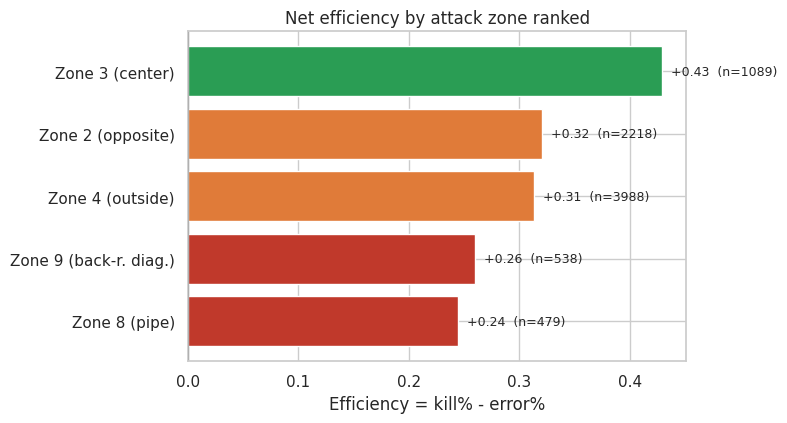

In [11]:
overall_zone = eff_stats(attacks_f, ["zone"]).set_index("zone").reindex(zone_order).reset_index()
overall_zone["zone_lbl"] = overall_zone.zone.map(zone_label)
overall_zone = overall_zone.sort_values("efficiency")

fig, ax = plt.subplots(figsize=(8, 4.4))
colors_div = ["#c0392b" if v < 0.30 else "#e07b39" if v < 0.38 else "#2a9d54"
for v in overall_zone.efficiency]
bars = ax.barh(overall_zone.zone_lbl, overall_zone.efficiency, color=colors_div)
ax.axvline(0, color="black", lw=0.8)
for y, (v, n) in enumerate(zip(overall_zone.efficiency, overall_zone.n)):
    ax.text(v + (0.008 if v >= 0 else -0.008), y, f"{v:+.2f}  (n={n})",
            va="center", ha="left" if v >= 0 else "right", fontsize=9)
ax.set_xlabel("Efficiency = kill% - error%")
ax.set_title("Net efficiency by attack zone ranked")
fig.tight_layout()
fig.savefig(f"{EDA_DIR}/fig4_zone_efficiency.png", dpi=160)

### Figures 5/6: zone x tempo efficiency heatmaps (small multiples) and sample size

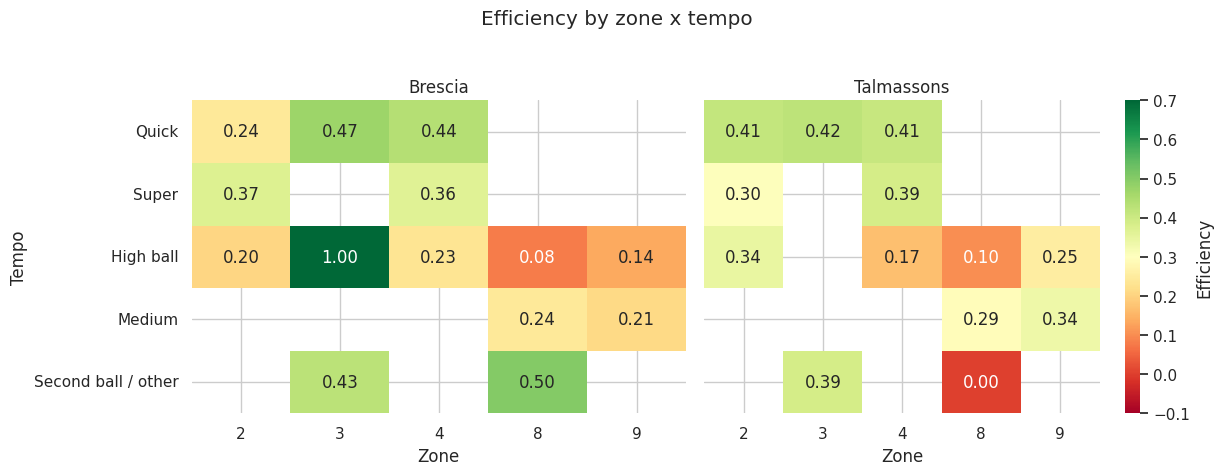

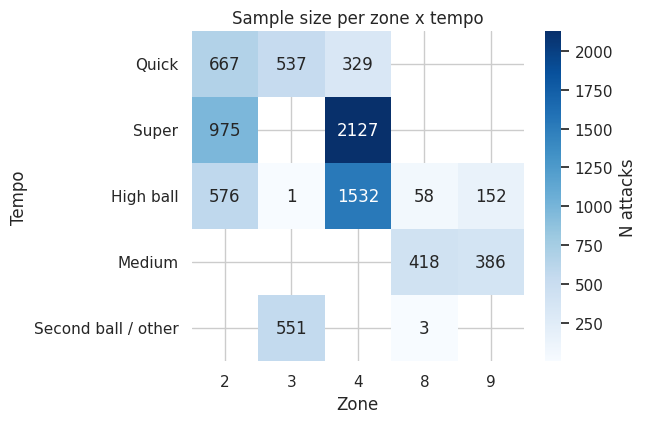

In [12]:
zt_team = eff_stats(attacks_f, ["team_label", "zone", "tempo_label"])
tempo_order = ["Quick", "Super", "High ball", "Medium", "Second ball / other"]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), sharey=True)
for i, team in enumerate(["Brescia", "Talmassons"]):
    sub = zt_team[zt_team.team_label == team]
    piv = sub.pivot_table(index="tempo_label", columns="zone", values="efficiency").reindex(
        index=tempo_order, columns=zone_order)
    sns.heatmap(piv, annot=True, fmt=".2f", cmap="RdYlGn", vmin=-0.1, vmax=0.7,
                ax=axes[i], cbar=(i == 1), cbar_kws={"label": "Efficiency"} if i == 1 else None)
    axes[i].set_title(team)
    axes[i].set_xlabel("Zone")
    axes[i].set_ylabel("" if i else "Tempo")
fig.suptitle("Efficiency by zone x tempo", y=1.03)
fig.tight_layout()
fig.savefig(f"{EDA_DIR}/fig5_efficiency_zonetempo.png", dpi=160, bbox_inches="tight")

zt_all = eff_stats(attacks_f, ["zone", "tempo_label"])
pivot_n_zt = zt_all.pivot_table(index="tempo_label", columns="zone", values="n").reindex(
    index=tempo_order, columns=zone_order)
fig, ax = plt.subplots(figsize=(6.5, 4.4))
sns.heatmap(pivot_n_zt, annot=True, fmt=".0f", cmap="Blues", ax=ax, cbar_kws={"label": "N attacks"})
ax.set_title("Sample size per zone x tempo")
ax.set_xlabel("Zone")
ax.set_ylabel("Tempo")
fig.tight_layout()
fig.savefig(f"{EDA_DIR}/fig6_sample_size_heatmap.png", dpi=160)


### Figure 7: match-level attack volume vs efficiency (seaborn jointplot)

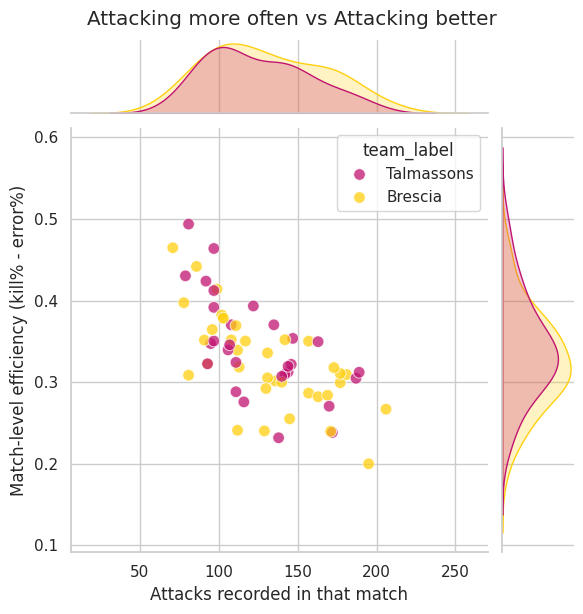

In [13]:
match_level = attacks_f.groupby(["match_id", "team_label"]).agg(
    n=("evaluation", "size"),
    kills=("evaluation", lambda s: (s == "#").sum()),
    errors=("evaluation", lambda s: (s == "=").sum()),
).reset_index()
match_level["efficiency"] = (match_level.kills - match_level.errors) / match_level.n
match_level = match_level[match_level.n >= 20]

g = sns.jointplot(data=match_level, x="n", y="efficiency", hue="team_label",
                   palette=TEAM_COLOR, height=6, alpha=0.75, s=70)
g.set_axis_labels("Attacks recorded in that match", "Match-level efficiency (kill% - error%)")
g.figure.suptitle("Attacking more often vs Attacking better", y=1.02)
g.savefig(f"{EDA_DIR}/fig7_jointplot_volume_efficiency.png", dpi=160, bbox_inches="tight")


### Figure 8: evaluation-scale usage Brescia vs Talmassons

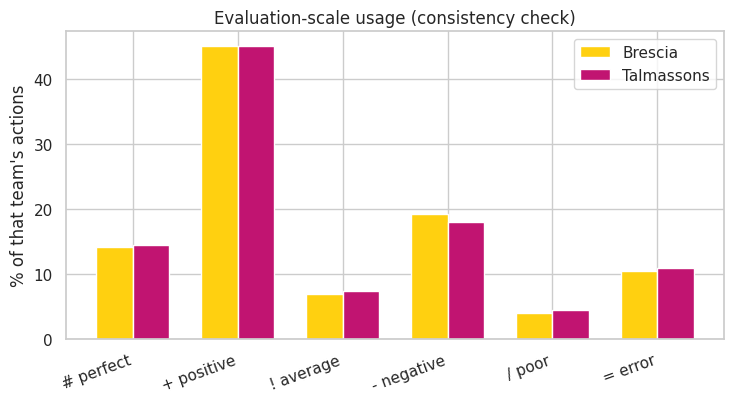

In [14]:
comp = actions[actions.team_code.isin(FOCAL)].copy()
comp["team_label"] = comp.team_code.map(TEAM_LABEL)
comp["_one"] = 1
ev_counts = comp.pivot_table(index="team_label", columns="evaluation", values="_one", aggfunc="sum", fill_value=0)
ev_by_team = (ev_counts.T / ev_counts.sum(axis=1)).T.reindex(columns=eval_order) * 100

fig, ax = plt.subplots(figsize=(7.5, 4.2))
grouped_bar(ax, [eval_label[e] for e in eval_order],
            ev_by_team.loc["Brescia"], ev_by_team.loc["Talmassons"],
            "Brescia", "Talmassons", TEAM_COLOR["Brescia"], TEAM_COLOR["Talmassons"],
            "% of that team's actions")
ax.set_title("Evaluation-scale usage (consistency check)")
fig.tight_layout()
fig.savefig(f"{EDA_DIR}/fig8_scout_consistency.png", dpi=160)


### Figures 9/10: the num_blockers anomaly visualized


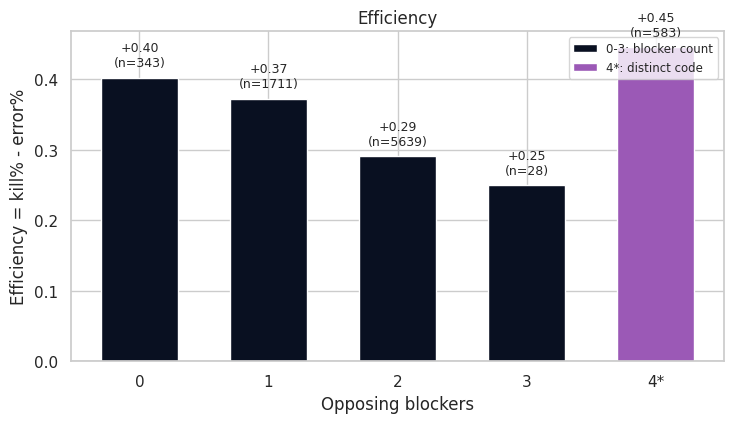

In [15]:
blk = attacks_f[attacks_f.num_blockers.isin(["0", "1", "2", "3", "4"])].copy()
blk_stats = eff_stats(blk, ["num_blockers"]).sort_values("num_blockers").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7.5, 4.4))
is_flagged = blk_stats.num_blockers == "4"
reliable = blk_stats[~is_flagged]
flagged = blk_stats[is_flagged]
ax.bar(reliable.index, reliable.efficiency, color="#091021", width=0.6,
       label="0-3: blocker count")
ax.bar(flagged.index, flagged.efficiency, color="#9b59b6", width=0.6,
       label="4*: distinct code")
for xi, (v, n, fl) in enumerate(zip(blk_stats.efficiency, blk_stats.n, is_flagged)):
    ax.text(xi, v + (0.012 if v >= 0 else -0.02), f"{v:+.2f}\n(n={n})",
            ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(blk_stats.index)
ax.set_xticklabels(["0", "1", "2", "3", "4*"])
ax.set_xlabel("Opposing blockers")
ax.set_ylabel("Efficiency = kill% - error%")
ax.set_title("Efficiency")
ax.legend(loc="upper right", frameon=True, fontsize=8.5)
fig.tight_layout()
fig.savefig(f"{EDA_DIR}/fig9_blockers.png", dpi=160)


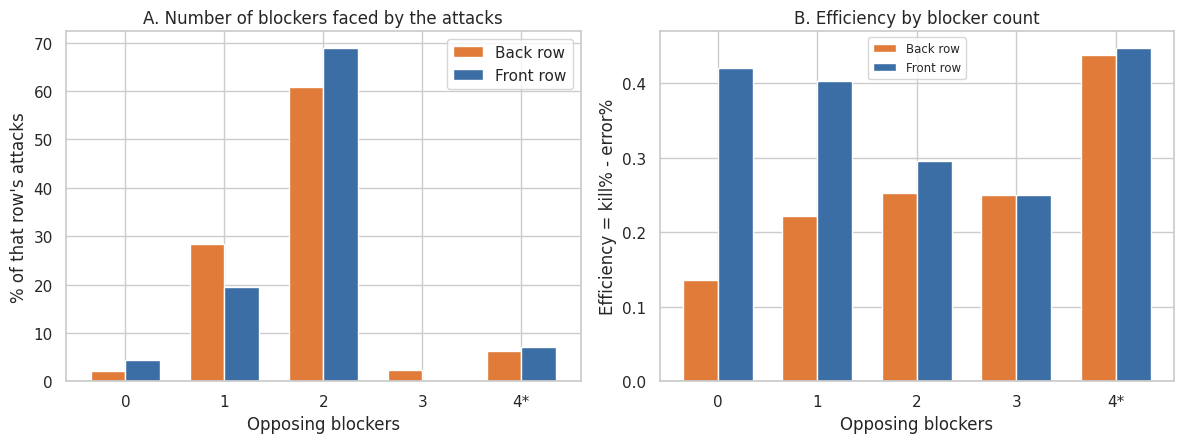

In [16]:
def _row_group(zone):
    if zone in FRONT_ZONES:
        return "Front row"
    if zone in BACK_ZONES:
        return "Back row"
    return "other"

blk2 = blk.copy()
blk2["row"] = blk2.zone.apply(_row_group)
blk2 = blk2[blk2.row != "other"]

blk2["_one"] = 1
row_counts = blk2.pivot_table(index="row", columns="num_blockers", values="_one", aggfunc="sum", fill_value=0)
row_dist = (row_counts.T / row_counts.sum(axis=1)).T.reindex(columns=["0", "1", "2", "3", "4"]) * 100
row_eff = eff_stats(blk2, ["row", "num_blockers"])
row_eff_piv = row_eff.pivot_table(index="num_blockers", columns="row", values="efficiency").reindex(
    ["0", "1", "2", "3", "4"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
row_dist.T.plot(kind="bar", ax=axes[0], color=["#e07b39", "#3b6ea5"], width=0.7)
axes[0].set_title("A. Number of blockers faced by the attacks")
axes[0].set_xlabel("Opposing blockers")
axes[0].set_ylabel("% of that row's attacks")
axes[0].set_xticklabels(["0", "1", "2", "3", "4*"], rotation=0)
axes[0].legend(title="")

xw = np.arange(5)
width = 0.35
axes[1].bar(xw - width/2, row_eff_piv["Back row"], width, color="#e07b39", label="Back row")
axes[1].bar(xw + width/2, row_eff_piv["Front row"], width, color="#3b6ea5", label="Front row")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xticks(xw)
axes[1].set_xticklabels(["0", "1", "2", "3", "4*"])
axes[1].set_xlabel("Opposing blockers")
axes[1].set_ylabel("Efficiency = kill% - error%")
axes[1].set_title("B. Efficiency by blocker count")
axes[1].legend(fontsize=8.5)
fig.tight_layout()
fig.savefig(f"{EDA_DIR}/fig10_frontback_blockers.png", dpi=160, bbox_inches="tight")


### Numeric summary

In [17]:
import json as _json
summary = {
    "n_matches": len(matches),
    "n_actions_total": len(actions),
    "n_attacks_total": len(attacks),
    "n_attacks_focal": len(attacks_f),
    "zone_stats_overall": overall_zone.to_dict("records"),
    "zone_stats_by_team": zv.to_dict("records"),
    "n_thin_cells": int((zt_all.n < 30).sum()),
    "n_total_cells": len(zt_all),
    "blocker_stats": blk_stats.to_dict("records"),
    "blocker_row_distribution_pct": row_dist.round(1).to_dict(),
    "blocker_row_efficiency": row_eff_piv.round(3).to_dict(),
    "eval_by_team": ev_by_team.round(1).to_dict(),
    "n_matches_used_jointplot": len(match_level),
    "corr_volume_efficiency": float(match_level["n"].corr(match_level["efficiency"])),
}
with open(f"{EDA_DIR}/summary3.json", "w") as f:
    _json.dump(summary, f, indent=2, default=str)
print(_json.dumps(summary, indent=2, default=str)[:2000])


{
  "n_matches": 63,
  "n_actions_total": 69943,
  "n_attacks_total": 16301,
  "n_attacks_focal": 8312,
  "zone_stats_overall": [
    {
      "zone": "8",
      "n": 479,
      "kills": 174,
      "errors": 57,
      "kill_rate": 0.36325678496868474,
      "error_rate": 0.11899791231732777,
      "efficiency": 0.24425887265135698,
      "zone_lbl": "Zone 8 (pipe)"
    },
    {
      "zone": "9",
      "n": 538,
      "kills": 190,
      "errors": 50,
      "kill_rate": 0.35315985130111527,
      "error_rate": 0.09293680297397769,
      "efficiency": 0.26022304832713755,
      "zone_lbl": "Zone 9 (back-r. diag.)"
    },
    {
      "zone": "4",
      "n": 3988,
      "kills": 1500,
      "errors": 249,
      "kill_rate": 0.37612838515546637,
      "error_rate": 0.06243731193580742,
      "efficiency": 0.313691073219659,
      "zone_lbl": "Zone 4 (outside)"
    },
    {
      "zone": "2",
      "n": 2218,
      "kills": 878,
      "errors": 167,
      "kill_rate": 0.3958521190261497,
   

## 4. Imports and constants


In [18]:
import numpy as np
import pandas as pd

from bokeh.io import output_notebook, output_file, save, show
from bokeh.plotting import figure
from bokeh.models import (
    ColumnDataSource, CDSView, GroupFilter, HoverTool, Div, Spinner
)
from bokeh.transform import factor_cmap
from bokeh.layouts import row, column, gridplot

DATA_DIR = "."
OUTPUT_HTML = "geography_of_the_attack.html"

FOCAL = ["BRE", "TAL"]
TEAM_LABEL = {"BRE": "Brescia", "TAL": "Talmassons"}

ZONE_ORDER = ["4", "3", "2", "8", "9"]
ZONE_LABEL = {
    "2": "Zone 2 (opposite)",
    "3": "Zone 3 (center)",
    "4": "Zone 4 (outside)",
    "8": "Zone 8 (pipe)",
    "9": "Zone 9 (back-r. diag.)",
}
# Real-proportioned zone rectangles: 9m x 9m half-court, 3 columns x 2 rows.
# Front row (near net) = zones 4/3/2
# back row = pipe(8)/9.
ZONE_RECT = {
    "4": {"x": 1.5, "y_bottom": 6, "y_top": 9},
    "3": {"x": 4.5, "y_bottom": 6, "y_top": 9},
    "2": {"x": 7.5, "y_bottom": 6, "y_top": 9},
    "8": {"x": 4.5, "y_bottom": 0, "y_top": 6},
    "9": {"x": 7.5, "y_bottom": 0, "y_top": 6},
}
ZONE_WIDTH = 3.0

TEMPO_LABEL = {
    "Q": "Quick", "H": "High ball", "U": "Super",
    "M": "Medium", "O": "Second ball / other", "N": "No-attack / rare",
}
TEMPO_ORDER = ["Quick", "Super", "High ball", "Medium", "Second ball / other"]

TIER_PALETTE = ["#c0392b", "#f4c542", "#2a9d54"]
TIER_ORDER = ["Low", "Medium", "High"]

TEAM_GROUPS = ["Both", "Brescia", "Talmassons"]

FRONT_ZONES = {"2", "3", "4"}
BACK_ZONES = {"8", "9"}
ROW_GROUPS = ["Both", "Front row", "Back row"]

BLK_ORDER = ["0", "1", "2", "3", "4"]
BLK_LABEL = {"0": "0", "1": "1", "2": "2", "3": "3", "4": "4*"}
BLK_CATS = [BLK_LABEL[b] for b in BLK_ORDER]

BLOCKER_TIER_PALETTE = TIER_PALETTE + ["#9b59b6"]
BLOCKER_TIER_ORDER = TIER_ORDER + ["Flagged"]


## 5. Load and prepare data


In [19]:
def load_attacks():
    actions = pd.read_csv(f"{DATA_DIR}/actions.csv", dtype=str)
    attacks = actions[(actions.skill == "A") & (actions.team_code.isin(FOCAL))].copy()
    attacks["team_label"] = attacks.team_code.map(TEAM_LABEL)
    attacks["tempo_label"] = attacks.tempo.map(TEMPO_LABEL).fillna(attacks.tempo)
    return attacks


def load_matches():
    return pd.read_csv(f"{DATA_DIR}/matches.csv", dtype=str)


def eff_row(df):
    n = len(df)
    kills = int((df.evaluation == "#").sum())
    errors = int((df.evaluation == "=").sum())
    blocked = int((df.evaluation == "/").sum())
    kr = kills / n if n else 0.0
    er = errors / n if n else 0.0
    br = blocked / n if n else 0.0
    return {"n": n, "kill_rate": kr, "error_rate": er, "block_rate": br, "efficiency": kr - er}


def tier(eff):
    if eff < 0.28:
        return "Low"
    elif eff < 0.38:
        return "Medium"
    return "High"


In [20]:
def build_zone_source(attacks):
    rows = []
    for zone in ZONE_ORDER:
        rect = ZONE_RECT[zone]
        for group in TEAM_GROUPS:
            sub = attacks[attacks.zone == zone] if group == "Both" \
                else attacks[(attacks.zone == zone) & (attacks.team_label == group)]
            stats = eff_row(sub)
            rows.append({
                "zone": zone, "zone_label": ZONE_LABEL[zone], "team_label": group,
                "x": rect["x"], "width": ZONE_WIDTH,
                "y_bottom": rect["y_bottom"], "y_top": rect["y_top"],
                **stats, "tier": tier(stats["efficiency"]),
            })
    df = pd.DataFrame(rows)
    return ColumnDataSource(df), df


def build_zone_tempo_source(attacks):
    rows = []
    for tempo in TEMPO_ORDER:
        for zone in ZONE_ORDER:
            sub = attacks[(attacks.tempo_label == tempo) & (attacks.zone == zone)]
            stats = eff_row(sub)
            rows.append({"zone": zone, "zone_label": ZONE_LABEL[zone],
                         "tempo_label": tempo, **stats, "tier": tier(stats["efficiency"])})
    df = pd.DataFrame(rows)
    return ColumnDataSource(df), df


def build_match_level_source(attacks, matches):
    rows = []
    for match_id, sub in attacks.groupby("match_id"):
        for team_code, tsub in sub.groupby("team_code"):
            tstats = eff_row(tsub)
            rows.append({
                "match_id": match_id,
                "team_label": TEAM_LABEL.get(team_code, team_code),
                **tstats,
            })
    df = pd.DataFrame(rows)
    return ColumnDataSource(df), df


def _blocker_tier(eff, is_flagged):
    if is_flagged:
        return "Flagged"
    return tier(eff)


def build_blocker_source(attacks):
    row_group_of = {}
    for z in FRONT_ZONES:
        row_group_of[z] = "Front row"
    for z in BACK_ZONES:
        row_group_of[z] = "Back row"
    attacks = attacks.copy()
    attacks["row_group"] = attacks.zone.map(row_group_of)

    blk = attacks[attacks.num_blockers.isin(BLK_ORDER)]
    rows = []
    for b in BLK_ORDER:
        for group in ROW_GROUPS:
            sub = blk[blk.num_blockers == b] if group == "Both" \
                else blk[(blk.num_blockers == b) & (blk.row_group == group)]
            stats = eff_row(sub)
            rows.append({
                "blocker_cat": BLK_LABEL[b], "row_group": group,
                **stats, "tier": _blocker_tier(stats["efficiency"], b == "4"),
            })
    df = pd.DataFrame(rows)
    return ColumnDataSource(df), df


## 6. Build the figures


In [21]:
def _draw_court_grid(p):
    p.line([0, 9, 9, 0, 0], [0, 0, 9, 9, 0], line_color="#888888", line_width=1)
    p.line([3, 3], [0, 9], line_color="#bbbbbb", line_width=1)
    p.line([6, 6], [0, 9], line_color="#bbbbbb", line_width=1)
    p.line([0, 9], [9, 9], line_color="black", line_width=4)
    p.line([0, 9], [6, 6], line_color="#888888", line_width=1, line_dash="dashed")


def make_court_diagram(zone_source):
    hover = HoverTool(tooltips=(
        "@zone_label (@team_label): efficiency @efficiency{0.00}, "
        "kill @kill_rate{0.0%}, error @error_rate{0.0%}, blocked @block_rate{0.0%} (n=@n)"
    ))

    zone_label_source = ColumnDataSource(data=dict(
        x=[ZONE_RECT[z]["x"] for z in ZONE_ORDER],
        y=[(ZONE_RECT[z]["y_bottom"] + ZONE_RECT[z]["y_top"]) / 2 for z in ZONE_ORDER],
        text=list(ZONE_ORDER),
    ))

    panels = []
    for group in TEAM_GROUPS:
        p = figure(height=340, width=300, title=group, toolbar_location=None,
                   tools=[hover, "box_select"], x_range=(0, 9), y_range=(0, 9.5))
        _draw_court_grid(p)

        view = CDSView(filter=GroupFilter(column_name="team_label", group=group))
        p.vbar(x="x", width="width", bottom="y_bottom", top="y_top",
               source=zone_source, view=view,
               color=factor_cmap("tier", palette=TIER_PALETTE, factors=TIER_ORDER),
               line_color="black", line_width=1, fill_alpha=0.85)

        p.text(x="x", y="y", text="text", source=zone_label_source,
               text_align="center", text_baseline="middle",
               text_font_size="14pt", text_font_style="bold", text_color="black")

        panels.append(p)

    panels[1].x_range = panels[0].x_range
    panels[1].y_range = panels[0].y_range
    panels[2].x_range = panels[0].x_range
    panels[2].y_range = panels[0].y_range

    return row(*panels)


def make_dot_plot(zone_source):
    view_both = CDSView(filter=GroupFilter(column_name="team_label", group="Both"))
    df = pd.DataFrame(zone_source.data)
    pooled = df[df.team_label == "Both"].sort_values("efficiency", ascending=True)
    zones_sorted = list(pooled["zone_label"])

    hover = HoverTool(tooltips="@zone_label: efficiency @efficiency{0.00} (n=@n)")
    p = figure(y_range=zones_sorted, height=320, width=520,
               title="Zones ranked by attack efficiency",
               toolbar_location=None, tools=[hover])
    p.hbar(y="zone_label", right="efficiency", height=0.05, source=zone_source,
           view=view_both, color="#999999")
    p.scatter(x="efficiency", y="zone_label", size=14, source=zone_source, view=view_both,
              color=factor_cmap("tier", palette=TIER_PALETTE, factors=TIER_ORDER),
              line_color="black")
    p.xaxis.axis_label = "Efficiency (kill% - error%)"
    return p


In [22]:
def make_tempo_small_multiples(tempo_source):
    hover = HoverTool(tooltips="@zone_label / @tempo_label: efficiency @efficiency{0.00} (n=@n)")
    figs = []
    for tempo in TEMPO_ORDER:
        p = figure(x_range=[ZONE_LABEL[z] for z in ZONE_ORDER], height=220, width=260,
                   title=tempo, toolbar_location=None, tools=[hover])
        p.xaxis.major_label_orientation = 0.9
        p.y_range.start = 0
        view = CDSView(filter=GroupFilter(column_name="tempo_label", group=tempo))
        p.vbar(x="zone_label", top="efficiency", width=0.6, source=tempo_source, view=view,
               color=factor_cmap("tier", palette=TIER_PALETTE, factors=TIER_ORDER))
        figs.append(p)
    return gridplot([[figs[0], figs[1], figs[2]], [figs[3], figs[4], None]])


def make_blocker_view(blocker_source):
    hover = HoverTool(tooltips=(
        "@row_group, @blocker_cat blockers: efficiency @efficiency{0.00} "
        "(kill @kill_rate{0.0%}, error @error_rate{0.0%}, n=@n)"
    ))

    panels = []
    for group in ROW_GROUPS:
        p = figure(x_range=BLK_CATS, height=300, width=300, title=group,
                   toolbar_location=None, tools=[hover])
        p.y_range.start = 0
        p.xaxis.axis_label = "Opposing blockers"
        p.yaxis.axis_label = "Efficiency" if group == "Both" else None

        view = CDSView(filter=GroupFilter(column_name="row_group", group=group))
        p.vbar(x="blocker_cat", top="efficiency", width=0.6,
               source=blocker_source, view=view,
               color=factor_cmap("tier", palette=BLOCKER_TIER_PALETTE, factors=BLOCKER_TIER_ORDER),
               line_color="black", line_width=1)
        panels.append(p)

    panels[1].y_range = panels[0].y_range
    panels[2].y_range = panels[0].y_range

    return row(*panels)


def make_volume_efficiency_view(match_source, match_df):
    hover = HoverTool(tooltips="Match @match_id (@team_label): n=@n, efficiency @efficiency{0.00}")
    main = figure(height=380, width=420, toolbar_location=None,
                  tools=[hover, "lasso_select", "box_select"],
                  title="Attack volume vs. efficiency")
    main.xaxis.axis_label = "Number of attacks in match"
    main.yaxis.axis_label = "Efficiency (kill% - error%)"

    view_bre = CDSView(filter=GroupFilter(column_name="team_label", group="Brescia"))
    view_tal = CDSView(filter=GroupFilter(column_name="team_label", group="Talmassons"))
    points_bre = main.scatter(x="n", y="efficiency", source=match_source, view=view_bre,
                               size=9, color="#1f77b4", legend_label="Brescia", alpha=0.75)
    points_tal = main.scatter(x="n", y="efficiency", source=match_source, view=view_tal,
                               size=9, color="#d62728", legend_label="Talmassons", alpha=0.75)
    main.legend.location = "top_right"

    spinner = Spinner(title="Point size", low=4, high=20, step=1, value=9, width=150)
    spinner.js_link("value", points_bre.glyph, "size")
    spinner.js_link("value", points_tal.glyph, "size")

    return column(main, spinner)


## 7. Assemble the page


In [23]:
attacks = load_attacks()
matches = load_matches()

zone_source, zone_df = build_zone_source(attacks)
tempo_source, tempo_df = build_zone_tempo_source(attacks)
match_source, match_df = build_match_level_source(attacks, matches)
blocker_source, blocker_df = build_blocker_source(attacks)

header = Div(text="""
<h2>The Geography of the Attack</h2>
<h3>Where points are won in the Italian Women's Serie A2</h3>

<p>This interactive dashboard compares the attacking patterns of Brescia and Talmassons,
the two teams promoted from the 2025/26 Serie A2 season. Use the charts below to
explore attack zones, tempo, blocking pressure, and attack efficiency.</p>
""", width=950)

court_note = Div(text="""
<h3>1. Court diagram: zone efficiency</h3>
<p>The court is drawn to scale (9 × 9 m half-court) and each rectangle represents
one attack zone. Front-row attacks (Zones 4, 3, and 2) are shown near the net,
while back-row attacks (Zones 8 and 9) are shown behind the 3-metre line.
The back-left area is intentionally left blank because it is not coded as a separate attack zone in the DataVolley data.</p>
<p>Colours represent three efficiency levels (Low, Medium, and High) using
<code>factor_cmap</code>. Hover over each zone to view kill rate, error rate,
block rate, net efficiency, and sample size. The three panels (Both teams,
Brescia, and Talmassons) share the same data source and are filtered using
<code>CDSView</code> and <code>GroupFilter</code>.</p>
""", width=950)

dot_note = Div(text="""
<h3>2. Ranked view </h3>
<p>The same pooled data are shown as a ranked dot plot. Each zone is ordered by
net efficiency, making it easier to compare the ranking than in the court view.
The plot is built with a thin <code>hbar</code> and a <code>scatter</code> marker.</p>
""", width=950)

tempo_note = Div(text="""
<h3>3. Zone efficiency by attack tempo</h3>
<p>The charts are grouped by attack tempo using <code>CDSView</code> and
<code>GroupFilter</code>. Data from both teams are combined to avoid very small
sample sizes. The number of opposing blockers is shown separately in Section 5.</p>
""", width=950)

blocker_note = Div(text="""
<h3>5. Blocking pressure: front row vs. back row</h3>
<p>This view groups attacks by the number of opposing blockers. Separate panels for
front-row attacks (Zones 2, 3, and 4) and back-row attacks (Zones 8 and 9) are
created using <code>CDSView</code> and <code>GroupFilter</code>.
The values from 0 to 3 indicate the number of opposing blockers. The additional
category (<code>4*</code>) represents a <i>hole block</i>: the attack passes
through a gap in the block rather than being classified by the number of
blockers. It is therefore shown as a separate category using
<code>factor_cmap</code>.</p>""", width=950)

vol_note = Div(text="""
<h3>4. Attack volume vs efficiency</h3>
<p>Each point represents one team's performance in one match. The lasso and box
selection tools can be used to highlight groups of matches, while the Spinner
changes the point size through <code>js_link</code>, without requiring custom
JavaScript.</p>
""", width=950)


layout = column(
    header,
    court_note,
    make_court_diagram(zone_source),
    dot_note,
    make_dot_plot(zone_source),
    tempo_note,
    make_tempo_small_multiples(tempo_source),
    vol_note,
    make_volume_efficiency_view(match_source, match_df),
    blocker_note,
    make_blocker_view(blocker_source),
)


## 8. Render inline, right here in Colab


In [24]:
output_notebook()
show(layout)


## 9. Export a standalone HTML file


In [25]:
output_file(OUTPUT_HTML, title="The Geography of the Attack")
save(layout)

from google.colab import files
files.download(OUTPUT_HTML)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>